**News Sentiment as a Trading Signal: Measuring Predictive Decay Across Holding Horizons**

Syed Sirajuddin · Master of Science in Applied Artificial Intelligence · Shiley Marcos School of Engineering, University of San Diego · AAI-590 Capstone

# Notebook 5 of 5 — Optimization, Analysis, and Discussion

This notebook contains the Model Optimization and the Analysis/Discussion elements of the code base, feeding the Methodology (optimization procedure), Results, and Conclusion sections of the report. The optimization *procedure* is fully specified and implemented here; the resulting numbers, figures, and their discussion are placeholders until model training and testing complete, per the project schedule.


In [1]:
%matplotlib inline
# Environment setup: resolve the repository root so `src` imports work
# whether this notebook is run from notebooks/ or the project root.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
RANDOM_SEED = 42

## 1. Optimization Procedure

Three signal hyperparameters are tuned: the sentiment entry threshold, the rolling aggregation window, and the minimum article support. The grid is deliberately coarse (three to four values per parameter) and the protocol strict, because hyperparameter search over backtests is the canonical route to overfitting — with enough trials, a "profitable" configuration emerges from noise alone (Bailey et al., 2014). Three rules keep the search honest: (1) the grid is evaluated **only on the in-sample period** (before January 2024); (2) the single configuration selected in-sample is then evaluated **once** on the out-of-sample window, and that number is final; and (3) the selection criterion is in-sample Sharpe at the *median* horizon rather than the best horizon, so the horizon-decay result is not contaminated by having been selected on.


In [2]:
from itertools import product
from src.config import PROCESSED_DIR, UNIVERSE, BACKTEST, SIGNALS
from src.features.aggregate import daily_sentiment_panel
from src.features.technicals import add_technicals
from src.signals.generate import generate_signals
from src.backtest.engine import run_horizon
from src.backtest.metrics import sharpe_ratio

prices = pd.read_parquet(PROCESSED_DIR / "prices_clean.parquet")
scored = pd.read_parquet(PROCESSED_DIR / "news_scored.parquet")
trading_days = pd.DatetimeIndex(prices["date"].drop_duplicates().sort_values())
prices_feat = add_technicals(prices)
oos = pd.Timestamp(BACKTEST.oos_start)
prices_is = prices[prices["date"] < oos]

# --- Guard the split: news begins 2022-03, so the in-sample window must
#     contain news AND leave a non-trivial out-of-sample period. ---
news_start = pd.to_datetime(scored["effective_date"]).min()
news_end   = pd.to_datetime(scored["effective_date"]).max()
print(f"News spans {news_start.date()} to {news_end.date()}")
print(f"Out-of-sample boundary (BACKTEST.oos_start): {oos.date()}")
assert oos > news_start, (
    f"oos_start {oos.date()} is at/before news start {news_start.date()} -- "
    "the in-sample period would contain no news. Set oos_start in config.py "
    "to a date inside the news window (e.g. 2025-01-01).")
assert oos < news_end, (
    f"oos_start {oos.date()} is at/after news end {news_end.date()} -- "
    "there would be no out-of-sample period.")
n_is = (pd.to_datetime(scored["effective_date"]) < oos).mean()
print(f"In-sample share of news: {n_is:.0%} | out-of-sample share: {1-n_is:.0%}")

GRID = {"long_threshold": [0.25, 0.35, 0.45],
        "sentiment_window": [1, 3, 5],
        "min_articles": [1, 2, 3]}
SELECTION_HORIZON = 10  # median of the horizon grid

rows = []
for thr, win, min_a in product(*GRID.values()):
    SIGNALS.long_threshold, SIGNALS.short_threshold = thr, -thr
    SIGNALS.sentiment_window, SIGNALS.min_articles = win, min_a
    panel = daily_sentiment_panel(scored, trading_days, UNIVERSE.tickers)
    sigs = generate_signals(panel, prices_feat)
    sigs_is = sigs[sigs["date"] < oos]
    res = run_horizon(sigs_is, prices_is, SELECTION_HORIZON)
    rows.append({"threshold": thr, "window": win, "min_articles": min_a,
                 "n_trades": len(res.trades),
                 "is_sharpe": sharpe_ratio(res.daily_returns)})

grid_results = pd.DataFrame(rows).sort_values("is_sharpe", ascending=False)
grid_results.head(10)

News spans 2022-03-01 to 2025-12-30
Out-of-sample boundary (BACKTEST.oos_start): 2025-01-01
In-sample share of news: 30% | out-of-sample share: 70%


,threshold,window,min_articles,n_trades,is_sharpe
18,0.45,1,1,656,0.124538
3,0.25,3,1,673,0.102791
2,0.25,1,3,547,0.088136
23,0.45,3,3,440,0.079920
0,0.25,1,1,678,0.000862
5,0.25,3,3,639,-0.019180
15,0.35,5,1,508,-0.034237
10,0.35,1,2,629,-0.039608
4,0.25,3,2,654,-0.053188
17,0.35,5,3,473,-0.067752


### Freezing the selected configuration

The grid search above mutates the global `SIGNALS` object on every iteration, so after the loop it holds the *last* combination tried, not the best one. The cell below explicitly writes the **grid winner** (highest in-sample Sharpe at the selection horizon) back into `SIGNALS`, so that every subsequent stage — the LSTM comparison and the final out-of-sample evaluation — uses the configuration that was actually selected. Without this step the "final" results would silently reflect leftover loop state.

Per the protocol, the winner is chosen on the **in-sample** period only, and this frozen configuration is then evaluated **once** on the untouched out-of-sample window.

In [3]:
# Freeze the selected configuration into SIGNALS (fixes leftover-loop-state bug).
best = grid_results.iloc[0]
SIGNALS.long_threshold   = float(best["threshold"])
SIGNALS.short_threshold  = -float(best["threshold"])
SIGNALS.sentiment_window = int(best["window"])
SIGNALS.min_articles     = int(best["min_articles"])

print("Selected configuration (grid winner, by in-sample Sharpe):")
print(f"  long/short threshold : +/-{SIGNALS.long_threshold}")
print(f"  sentiment window     : {SIGNALS.sentiment_window} trading day(s)")
print(f"  min articles         : {SIGNALS.min_articles}")
print(f"  in-sample Sharpe (H={SELECTION_HORIZON}d): {best['is_sharpe']:.3f}, "
      f"{int(best['n_trades'])} trades")

# Sanity check on selection robustness: how tightly clustered are the top configs?
top = grid_results.head(5)["is_sharpe"]
print(f"\nTop-5 in-sample Sharpe spread: {top.min():.3f} to {top.max():.3f} "
      f"(range {top.max()-top.min():.3f})")
print("NOTE: if this range is small, the configurations are statistically "
      "close; report the choice with appropriate caution (Bailey et al., 2014).")

# Rebuild the panel/signals ONCE under the frozen config for all downstream use.
panel = daily_sentiment_panel(scored, trading_days, UNIVERSE.tickers)
signals_final = generate_signals(panel, prices_feat)
print(f"\nSignals under selected config: {len(signals_final)}")

Selected configuration (grid winner, by in-sample Sharpe):
  long/short threshold : +/-0.45
  sentiment window     : 1 trading day(s)
  min articles         : 1
  in-sample Sharpe (H=10d): 0.125, 656 trades

Top-5 in-sample Sharpe spread: 0.001 to 0.125 (range 0.124)
NOTE: if this range is small, the configurations are statistically close; report the choice with appropriate caution (Bailey et al., 2014).

Signals under selected config: 3293


**Selected configuration — to be completed after the in-sample search.** The chosen values will be fixed in `src/config.py`, and every subsequent number in this notebook will use them.

## 2. Optional Learned Signal: LSTM Combiner

As a model-comparison extension (scheduled as the first item to be cut if time runs short), a recurrent sequence model combines rolling sentiment with price context to *learn* the entry signal rather than hard-coding thresholds. The architecture is a stacked LSTM (Hochreiter & Schmidhuber, 1997) — two recurrent layers of 64 and 32 units with dropout 0.2 between them, followed by a 16-unit ReLU layer and a sigmoid output — trained with binary cross-entropy and Adam (10⁻³) to predict the sign of the forward return from 20-day sequences of six features. Two leakage controls mirror the backtest discipline: a strictly chronological train/test split at the out-of-sample boundary, and feature normalization using training-period statistics only. Comparing the learned signal's decay curve to the rule-based one tests whether the decay is a property of the *information* or of our particular rule.


In [4]:
from src.models.sequence import train, build_dataset

# Uses the panel built under the frozen configuration above.
model, history, oos_preds = train(panel, prices_feat, horizon=5)
model.summary()

Epoch 1/30
34/34 - 3s - 75ms/step - accuracy: 0.5117 - auc: 0.5103 - loss: 0.6933 - val_accuracy: 0.5432 - val_auc: 0.5324 - val_loss: 0.6884
Epoch 2/30
34/34 - 1s - 22ms/step - accuracy: 0.5378 - auc: 0.5264 - loss: 0.6905 - val_accuracy: 0.5479 - val_auc: 0.5319 - val_loss: 0.6884
Epoch 3/30
34/34 - 1s - 23ms/step - accuracy: 0.5376 - auc: 0.5349 - loss: 0.6893 - val_accuracy: 0.5452 - val_auc: 0.4629 - val_loss: 0.6915
Epoch 4/30
34/34 - 1s - 23ms/step - accuracy: 0.5509 - auc: 0.5587 - loss: 0.6863 - val_accuracy: 0.5776 - val_auc: 0.5370 - val_loss: 0.6837
Epoch 5/30
34/34 - 1s - 23ms/step - accuracy: 0.5579 - auc: 0.5623 - loss: 0.6852 - val_accuracy: 0.5531 - val_auc: 0.5285 - val_loss: 0.6885
Epoch 6/30
34/34 - 1s - 23ms/step - accuracy: 0.5580 - auc: 0.5670 - loss: 0.6841 - val_accuracy: 0.5241 - val_auc: 0.5107 - val_loss: 0.6923
Epoch 7/30
34/34 - 1s - 22ms/step - accuracy: 0.5625 - auc: 0.5759 - loss: 0.6822 - val_accuracy: 0.5274 - val_auc: 0.4857 - val_loss: 0.6926
Epoch 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,413 (364.90 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,276 (243.27 KB)

**LSTM training curves and out-of-sample AUC — to be completed after training.**

## 3. Results (placeholder)

To be completed after live-data testing. This section will present, for the selected configuration and each holding horizon on the out-of-sample window: the horizon comparison table (trade counts, hit rate, average net trade return, Sharpe ratio, maximum drawdown) with the random-null 95th-percentile band; the decay-curve figure; the post-signal event study; and equity curves against buy-and-hold. The discussion will state plainly at which horizons, if any, the strategy's Sharpe exceeds the null band, and how transaction costs reshape the gross-signal decay.


Out-of-sample signals (date >= 2025-01-01): 882


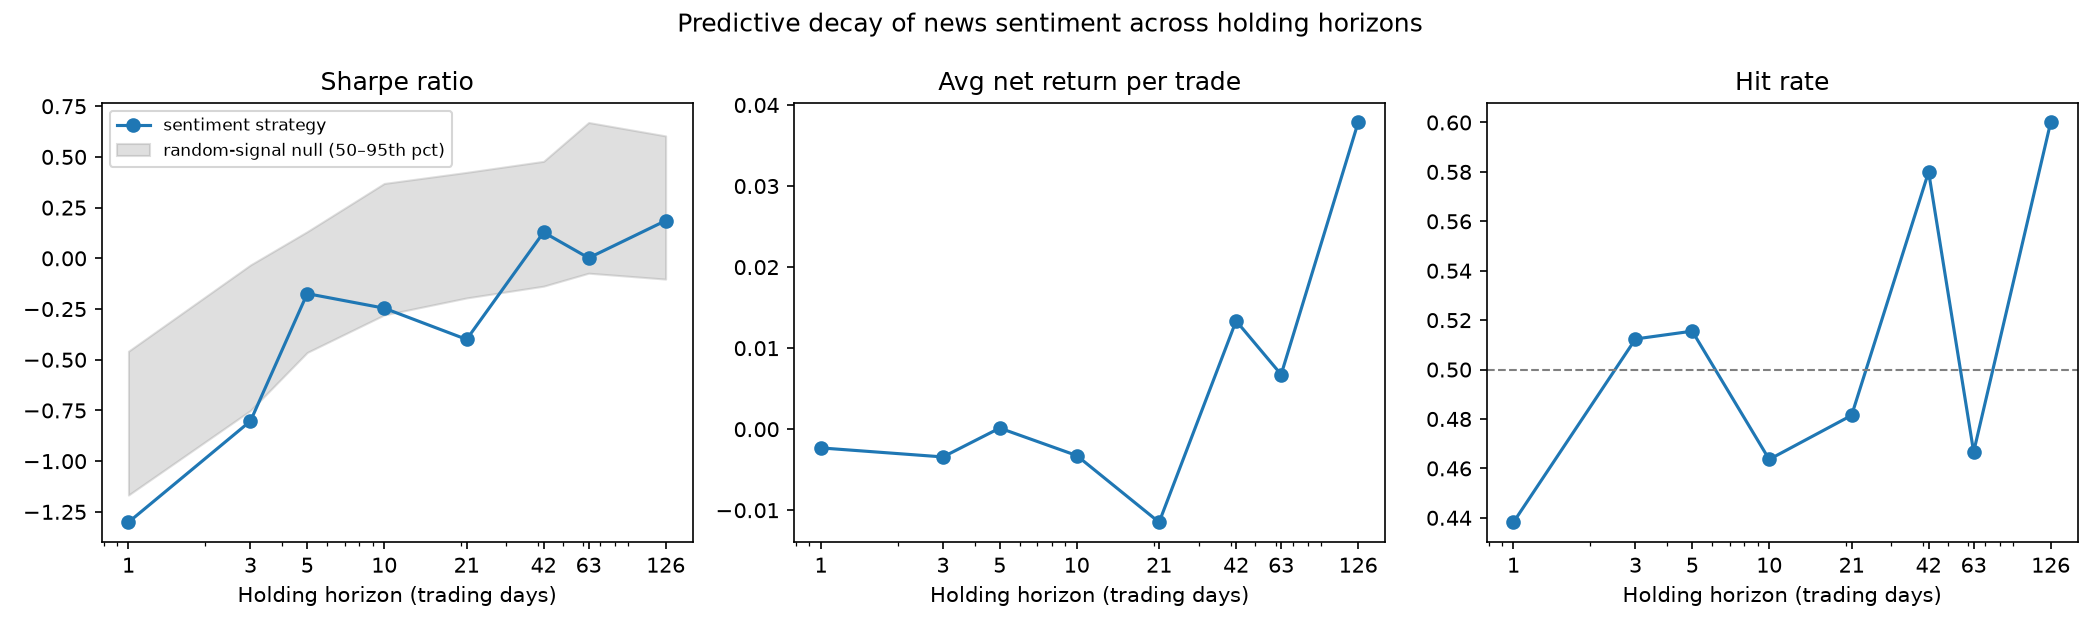

,strategy,cum_return,ann_return,ann_vol,sharpe,max_drawdown,n_trades,hit_rate,avg_trade_ret,null_sharpe_median,null_sharpe_p95,beats_null_p95,low_confidence
horizon,,,,,,,,,,,,,
1,H=1d,-0.588,-0.138,0.109,-1.301,-0.598,712,0.438,-0.002,-1.167,-0.458,False,False
3,H=3d,-0.347,-0.069,0.084,-0.802,-0.381,525,0.512,-0.003,-0.750,-0.033,False,False
5,H=5d,-0.071,-0.012,0.061,-0.174,-0.164,386,0.516,0.000,-0.464,0.132,False,False
10,H=10d,-0.082,-0.014,0.053,-0.246,-0.162,220,0.464,-0.003,-0.279,0.369,False,False
21,H=21d,-0.141,-0.025,0.059,-0.400,-0.188,108,0.481,-0.011,-0.195,0.424,False,False
42,H=42d,0.037,0.006,0.064,0.128,-0.178,50,0.580,0.013,-0.137,0.478,False,False
63,H=63d,-0.006,-0.001,0.048,0.002,-0.100,30,0.467,0.007,-0.073,0.670,False,True
126,H=126d,0.032,0.005,0.031,0.186,-0.053,10,0.600,0.038,-0.102,0.604,False,True


In [5]:
# Final out-of-sample evaluation -- executed once, on the frozen selected
# configuration, over the untouched out-of-sample window. See Notebook 04
# for the engine and baselines.
from src.backtest.engine import run_all_horizons
from src.backtest.baselines import buy_and_hold, random_signals_null
from src.analysis.horizon_decay import horizon_table, plot_decay_curve

sigs_oos = signals_final[signals_final["date"] >= oos]
print(f"Out-of-sample signals (date >= {oos.date()}): {len(sigs_oos)}")

results = run_all_horizons(sigs_oos, prices)
nulls = {h: random_signals_null(sigs_oos, prices, h, n_sims=100)
         for h in BACKTEST.horizons}
final_table = horizon_table(results, nulls)

# Flag low-confidence horizons (few trades) so they are not over-read.
final_table["low_confidence"] = final_table["n_trades"] < 50

# Plot the decay curve (saves to reports/figures/) and show it inline.
plot_decay_curve(final_table)
from IPython.display import Image, display as idisplay
_p = ROOT / "reports" / "figures" / "decay_sharpe.png"
if _p.exists():
    idisplay(Image(filename=str(_p)))

final_table.round(3)

## 4. Conclusion (placeholder)

To be completed after Results. This section will summarize the hypothesis test — whether sentiment-driven signals beat the baselines at swing horizons and lose their edge as the holding period lengthens — highlight the most significant or unexpected finding, and outline future work: expanding the universe beyond large caps, richer text inputs (full articles, earnings-call transcripts), regime-conditional analysis, and the productionization path (streaming ingestion, scheduled scoring, and monitoring for sentiment-model drift).


---
### Acknowledgment of AI Tool Use

Portions of the code scaffolding and prose in this notebook were drafted with the assistance of Anthropic's Claude (Anthropic, 2026) and subsequently reviewed, tested, and revised by the author, who takes full responsibility for the final content, design decisions, and results. This acknowledgment is provided in accordance with University of San Diego academic integrity guidelines on the use of generative AI tools.

Anthropic. (2026). *Claude* [Large language model]. https://claude.ai

### References

Bailey, D. H., Borwein, J. M., López de Prado, M., & Zhu, Q. J. (2014). Pseudo-mathematics and financial charlatanism: The effects of backtest overfitting on out-of-sample performance. *Notices of the American Mathematical Society, 61*(5), 458–471.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780.
